# Laboratorio 7 — Exploración de relaciones y patrones

## Analítica de Datos

En los laboratorios anteriores analizamos las variables del conjunto de datos de **Andina Retail** de manera individual. Estudiamos su posición, dispersión y la presencia de valores potencialmente atípicos.

En este laboratorio cambiaremos la perspectiva: pasaremos del **análisis univariado** al **análisis bivariado**, estudiando cómo se comportan dos variables conjuntamente.

Analizaremos dos tipos de relaciones:

- **Numérica – numérica:** `unidades` ↔ `ventas`
- **Categórica – numérica:** `categoria` ↔ `ventas`

### Objetivos

Al finalizar el laboratorio podremos:

- representar la relación entre dos variables numéricas mediante un diagrama de dispersión;
- identificar visualmente patrones de asociación;
- calcular e interpretar el coeficiente de correlación de Pearson;
- analizar el efecto de valores potencialmente atípicos sobre una relación;
- comparar la distribución de una variable numérica entre diferentes categorías;
- diferenciar asociación estadística de causalidad.

## 1. Preparación del entorno

Comenzaremos importando las bibliotecas necesarias para realizar el análisis.

Utilizaremos:

- `pandas` para trabajar con los datos;
- `matplotlib.pyplot` para construir visualizaciones;
- `seaborn` para facilitar la representación gráfica de las relaciones entre variables.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del conjunto de datos

Continuaremos trabajando con el conjunto de datos de **Andina Retail** utilizado en los laboratorios anteriores.

Cargaremos el archivo y visualizaremos las primeras observaciones para verificar que los datos se hayan importado correctamente.

In [2]:
df = pd.read_csv("/content/ventas_preparadas.csv")
df.head()

,fecha,id_cliente,producto,categoria,ciudad,unidades,precio_unitario,descuento,canal,ventas
0,2025-11-03,13375,Guantes gym,Deportes,Bogota,4,48100.0,0.05,En linea,182780.0
1,2025-06-05,19441,Licuadora,Hogar,Barranquilla,5,81800.0,0.00,Tienda,409000.0
2,2025-06-02,10603,Tapete yoga,Deportes,Bogota,2,75200.0,0.10,En linea,135360.0
3,2025-11-15,10698,Bicicleta estatica,Deportes,Bogota,3,42300.0,0.00,Tienda,126900.0
4,2025-08-29,15539,Tenis urbanos,Moda,Cali,1,94500.0,0.05,Tienda,89775.0


## 3. Identificación de las variables de interés

Antes de analizar una relación debemos reconocer el tipo de variables que estamos comparando.

En la primera parte estudiaremos:

- `unidades`: variable numérica que representa la cantidad de unidades vendidas.
- `ventas`: variable numérica que representa el valor de la transacción.

Por tanto, realizaremos un análisis **numérico – numérico**.

### Pregunta de análisis

**¿Existe algún patrón entre la cantidad de unidades vendidas y el valor de las ventas?**

In [3]:
df[["unidades", "ventas"]].head(10)

,unidades,ventas
0,4,182780.0
1,5,409000.0
2,2,135360.0
3,3,126900.0
4,1,89775.0
5,2,1194400.0
6,2,208420.0
7,1,30940.0
8,3,661230.0
9,1,70100.0


### E:Identifique las variables

Observe las variables `unidades` y `ventas` mostradas en la tabla anterior.

1. ¿Qué representa la variable `unidades`?
2. ¿Qué representa la variable `ventas`?
3. ¿Qué tipo de variable es cada una?
4. ¿Es suficiente observar algunas filas de la tabla para determinar si existe una relación entre `unidades` y `ventas`?
5. ¿Qué representación gráfica podría ayudarnos a explorar esta relación?

## 4. Cuantificación de la relación: correlación de Pearson

Para cuantificarla utilizaremos el **coeficiente de correlación de Pearson**, cuyo valor se encuentra entre -1 y 1:

- valores cercanos a **1** indican una relación lineal positiva más marcada;
- valores cercanos a **-1** indican una relación lineal negativa más marcada;
- valores cercanos a **0** indican una relación lineal débil o inexistente.

Calcularemos primero la correlación utilizando todas las transacciones.

In [4]:
correlacion_completa = df["unidades"].corr(df["ventas"])
print("Correlación con todas las observaciones:")
print(correlacion_completa)

Correlación con todas las observaciones:
0.48740482134227014


### Interprete el coeficiente de correlación

El coeficiente de correlación de Pearson obtenido fue:

**r = 0.487**

A partir de este resultado, responda:

1. ¿El coeficiente indica una relación positiva o negativa entre `unidades` y `ventas`?
2. ¿Cómo describiría la magnitud de la relación lineal observada?
3. ¿Una correlación positiva significa que todas las transacciones con más unidades presentan necesariamente mayores ventas?
4. ¿Este resultado permite afirmar que el número de unidades es la causa del valor de las ventas?

## 4.1. Efecto de una observación extrema sobre la correlación

En el análisis anterior identificamos una transacción de **500 unidades**, considerablemente alejada del comportamiento habitual de la variable `unidades`.

El coeficiente de correlación calculado con todas las observaciones fue aproximadamente:

**r = 0.487**

Para evaluar cuánto influye esta observación sobre el coeficiente de Pearson, la retiraremos **temporalmente** y calcularemos nuevamente la correlación.

> **Importante:** retirar temporalmente una observación para estudiar su influencia no significa que el dato sea incorrecto ni que deba eliminarse definitivamente.

In [5]:
df_sin_extremo = df[df["unidades"] != 500]
correlacion_sin_extremo = df_sin_extremo["unidades"].corr(
    df_sin_extremo["ventas"]
)
print("Correlación con todas las observaciones:", correlacion_completa)
print("Correlación sin la observación extrema:", correlacion_sin_extremo)

Correlación con todas las observaciones: 0.48740482134227014
Correlación sin la observación extrema: 0.19464924028612635


### Compare los coeficientes de correlación

Los resultados obtenidos fueron:

- Con todas las observaciones: **r = 0.487**
- Sin la observación extrema: **r = 0.195**

Responda:

1. ¿Cómo cambió la correlación al retirar la observación extrema?
2. ¿Cómo interpretaría la relación entre `unidades` y `ventas` en cada caso?
3. ¿Qué indica este resultado sobre la influencia de una observación extrema en el coeficiente de Pearson?
4. ¿Por qué es importante observar el diagrama de dispersión antes de interpretar una correlación?

## 5. Relación entre una variable categórica y una variable numérica

Hasta ahora analizamos la relación entre dos variables numéricas: `unidades` y `ventas`.

Sin embargo, no todas las relaciones se estudian de la misma manera. Cuando una variable es **categórica** y la otra es **numérica**, podemos comparar cómo se distribuye la variable numérica entre los diferentes grupos.

En esta sección analizaremos:

- `categoria`: variable categórica.
- `ventas`: variable numérica.

### Pregunta de análisis

**¿La distribución de las ventas presenta diferencias entre las categorías de productos?**

Para explorarlo utilizaremos diagramas de caja (*boxplots*).

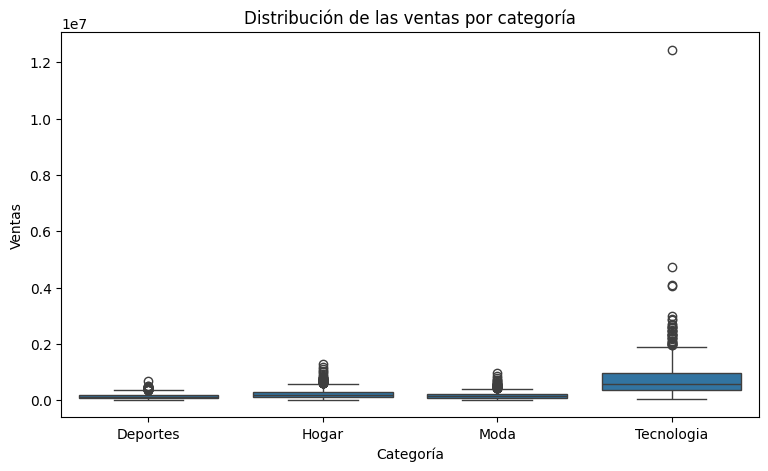

In [6]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="categoria",
    y="ventas"
)
plt.title("Distribución de las ventas por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas")
plt.show()

### Comparación detallada de las distribuciones

El gráfico anterior permite identificar valores potencialmente atípicos, pero las observaciones de ventas muy elevadas amplían considerablemente la escala y dificultan comparar las cajas entre categorías.

Para observar con mayor detalle la posición y dispersión de la mayoría de las transacciones, construiremos nuevamente el boxplot limitando únicamente el rango visible del eje vertical.

> **Importante:** los datos no serán eliminados. Solamente modificaremos la escala utilizada para visualizar el gráfico.

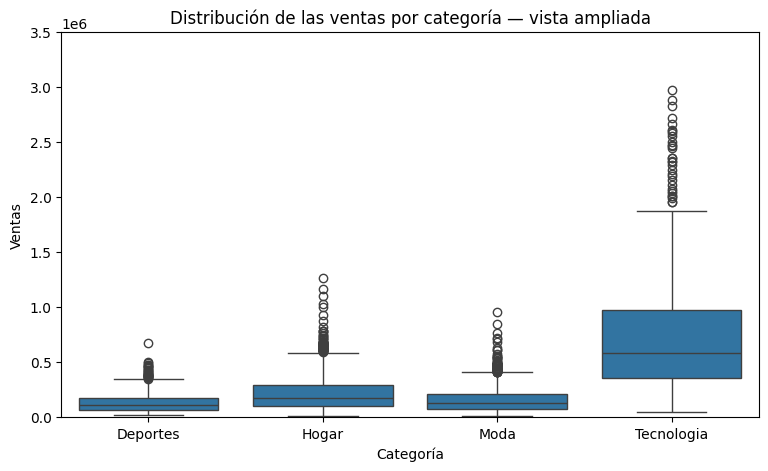

In [8]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="categoria",
    y="ventas"
)
plt.ylim(0, 3500000)
plt.title("Distribución de las ventas por categoría — vista ampliada")
plt.xlabel("Categoría")
plt.ylabel("Ventas")
plt.show()

### Interprete la comparación entre categorías

Observe la distribución de las ventas para cada categoría y responda:

1. ¿Qué categoría presenta la mediana de ventas más alta?
2. ¿Qué categoría presenta mayor dispersión en el 50 % central de los datos?
3. ¿Qué diferencias observa entre la distribución de Tecnología y las demás categorías?
4. ¿En todas las categorías se observan valores potencialmente atípicos?
5. ¿Qué información aporta esta comparación que no obtendríamos analizando únicamente la variable `ventas` de manera global?

## 6. Cierre del Laboratorio 7

En este laboratorio analizamos relaciones entre variables desde dos perspectivas:

- **Numérica – numérica:** `unidades` ↔ `ventas`
- **Categórica – numérica:** `categoria` ↔ `ventas`

También observamos cómo una observación extrema puede modificar tanto una visualización como el coeficiente de correlación.

### Reflexión final

1. ¿Qué diferencia existe entre analizar una variable individualmente y analizar dos variables conjuntamente?

2. ¿Por qué no es recomendable interpretar un coeficiente de correlación sin observar también el diagrama de dispersión?

3. ¿Qué ocurrió con la correlación entre `unidades` y `ventas` cuando retiramos temporalmente la observación extrema?

4. ¿Qué permitió descubrir el análisis de `categoria` y `ventas` que no era evidente al estudiar únicamente las ventas globales?

5. ¿Podemos afirmar que las relaciones encontradas demuestran causalidad? Justifique brevemente.